### Research question
How do predator and prey populations dynamically coexist in a simple agent-based ecosystem, and how does the introduction of an invasive prey species destabilize or shift that equilibrium?

### What this notebook does
This notebook builds an agent-based predator–prey ecosystem model on a 2D grid. The goal is to study how native prey, predators, and later an invasive prey species interact over time, and how invasion changes the balance of the ecosystem.

- Native prey with energy tracking, starvation death, and reproduction
- Predators with vision-based hunting, energy metabolism, and reproduction  
- Invasive prey that compete aggressively via higher mobility and displacement  
- Food regrowth as a carrying-capacity mechanism  
- A baseline run (no invasion) vs. an invaded run with side-by-side comparison  
- Multi-trial averaging across random seeds to handle stochasticity  
- Statistical analysis: extinction rates, population variance, phase-space plots  
- Rich visualizations: animated grid snapshots, food overlay, full comparison dashboard

## 1. Imports and reproducibility
All external libraries are imported here. set_seed ensures each experiment is reproducible.

In [47]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from collections import defaultdict

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)

## 2. Agent classes

This part creates the native prey agents. Native prey move randomly, eat food from the environment to gain energy, lose energy each time step, reproduce when conditions are good, and die if their energy becomes too low. This makes them dependent on both food availability and predator pressure.

In [48]:
class NativePrey:
    """
    Native prey that move randomly, eat food, gain energy, and reproduce.

    Parameters:
    
    x, y : int
        Initial grid coordinates.
    
    energy : int
        Starting energy level.
    
    reproduce_prob : float
        Probability of reproduction when conditions are met.
    
    energy_gain : int
        Energy gained per food cell consumed.
    
    max_energy : int
        Energy cap (prevents unlimited accumulation).
    """

    def __init__(self, x: int, y: int, energy: int = 5,
                 reproduce_prob: float = 0.12, energy_gain: int = 3,
                 max_energy: int = 10):
        self.x = x
        self.y = y
        self.energy = energy
        self.reproduce_prob = reproduce_prob
        self.energy_gain = energy_gain
        self.max_energy = max_energy
        self.ate_this_step = False

    def move(self, width: int, height: int) -> None:
        """Move one cell in a random cardinal direction (or stay)."""
        dx, dy = random.choice([(1, 0), (-1, 0), (0, 1), (0, -1), (0, 0)])
        self.x = (self.x + dx) % width
        self.y = (self.y + dy) % height

    def lose_energy(self) -> None:
        """Subtract 1 energy per step (metabolism cost)."""
        self.energy -= 1

    def eat(self, food_grid: np.ndarray) -> bool:
        """Consume food at current cell if available; restore energy."""
        if food_grid[self.y, self.x]:
            food_grid[self.y, self.x] = False
            self.energy = min(self.max_energy, self.energy + self.energy_gain)
            self.ate_this_step = True
            return True
        self.ate_this_step = False
        return False

    def reproduce(self) -> "NativePrey | None":
        """Spawn an offspring if conditions are met."""
        if self.ate_this_step and self.energy >= 4 and random.random() < self.reproduce_prob:
            self.energy = max(1, self.energy - 2)
            return NativePrey(self.x, self.y, energy=4,
                              reproduce_prob=self.reproduce_prob,
                              energy_gain=self.energy_gain,
                              max_energy=self.max_energy)
        return None

    def is_alive(self) -> bool:
        """Return True if agent still has energy."""
        return self.energy > 0


This part creates the invasive prey agents. They are similar to native prey, but they are designed to be more competitive, such as moving farther or reproducing more effectively. Their purpose is to represent an introduced species that can disturb the original ecosystem.

In [49]:
class InvasivePrey:
    """
    Invasive prey with higher mobility, energy resilience, and competitive displacement.

    Invasive prey have an ecological edge over native prey:
    - Can move 1 or 2 cells per step.
    - Higher reproduction probability.
    - Displace native prey from shared cells.

    Parameters:
    x, y : int
        Initial grid coordinates.

    energy : int
        Starting energy level.
    
    reproduce_prob : float
        Probability of reproduction when conditions are met.
    
    energy_gain : int
        Energy gained per food cell consumed.
    
    max_energy : int
        Energy cap.
    """

    def __init__(self, x: int, y: int, energy: int = 6,
                 reproduce_prob: float = 0.18, energy_gain: int = 3,
                 max_energy: int = 12):
        self.x = x
        self.y = y
        self.energy = energy
        self.reproduce_prob = reproduce_prob
        self.energy_gain = energy_gain
        self.max_energy = max_energy
        self.ate_this_step = False

    def move(self, width: int, height: int) -> None:
        """Move 1 or 2 cells (biased toward 1) in a random cardinal direction."""
        step = random.choice([1, 1, 2])
        dx, dy = random.choice([(step, 0), (-step, 0), (0, step), (0, -step), (0, 0)])
        self.x = (self.x + dx) % width
        self.y = (self.y + dy) % height

    def lose_energy(self) -> None:
        """Subtract 1 energy per step."""
        self.energy -= 1

    def eat(self, food_grid: np.ndarray) -> bool:
        """Consume food at current cell if available; restore energy."""
        if food_grid[self.y, self.x]:
            food_grid[self.y, self.x] = False
            self.energy = min(self.max_energy, self.energy + self.energy_gain)
            self.ate_this_step = True
            return True
        self.ate_this_step = False
        return False

    def reproduce(self) -> "InvasivePrey | None":
        """Spawn an offspring if conditions are met."""
        if self.ate_this_step and self.energy >= 5 and random.random() < self.reproduce_prob:
            self.energy = max(1, self.energy - 2)
            return InvasivePrey(self.x, self.y, energy=5,
                                reproduce_prob=self.reproduce_prob,
                                energy_gain=self.energy_gain,
                                max_energy=self.max_energy)
        return None

    def is_alive(self) -> bool:
        """Return True if agent still has energy."""
        return self.energy > 0


This part creates the predator agents. Predators lose energy over time, search for prey, move toward nearby prey when possible, gain energy by eating prey, and reproduce if they have enough energy. This allows predator population growth to depend on hunting success.

In [50]:
class Predator:
    """
    Predator with vision-based hunting, energy metabolism, and reproduction.

    Predators scan a square neighbourhood of radius `vision` each step.
    If prey are visible, they move toward the closest one.
    Otherwise they random-walk.

    Parameters:
    x, y : int
        Initial grid coordinates.

    energy : int
        Starting energy level.
    
    energy_gain : int
        Energy gained per prey eaten.
    
    reproduce_energy : int
        Minimum energy required to reproduce.
    
    vision : int
        Chebyshev-distance radius for detecting prey.
    """

    def __init__(self, x: int, y: int, energy: int = 10,
                 energy_gain: int = 6, reproduce_energy: int = 18, vision: int = 2):
        self.x = x
        self.y = y
        self.energy = energy
        self.energy_gain = energy_gain
        self.reproduce_energy = reproduce_energy
        self.vision = vision

    def _step_toward(self, current: int, target: int, size: int) -> int:
        """Return +1, -1, or 0 to move current one step toward target on a torus."""
        forward = (target - current) % size
        backward = (current - target) % size
        if forward == 0:
            return 0
        return 1 if forward <= backward else -1

    
    def move(self, width: int, height: int, all_prey: list) -> None:
        """Move toward the nearest visible prey, or random-walk if none visible."""
        visible = []
        for prey in all_prey:
            dx = min(abs(prey.x - self.x), width  - abs(prey.x - self.x))
            dy = min(abs(prey.y - self.y), height - abs(prey.y - self.y))
            if max(dx, dy) <= self.vision:
                visible.append((dx + dy, prey))

        if visible and random.random() < 0.85:
            _, target = min(visible, key=lambda item: item[0])
            if random.random() < 0.5:
                step_x = self._step_toward(self.x, target.x, width)
                step_y = 0 if step_x != 0 else self._step_toward(self.y, target.y, height)
            else:
                step_y = self._step_toward(self.y, target.y, height)
                step_x = 0 if step_y != 0 else self._step_toward(self.x, target.x, width)
            self.x = (self.x + step_x) % width
            self.y = (self.y + step_y) % height
            return

        dx, dy = random.choice([(1, 0), (-1, 0), (0, 1), (0, -1), (0, 0)])
        self.x = (self.x + dx) % width
        self.y = (self.y + dy) % height

    def lose_energy(self) -> None:
        """Subtract 1 energy per step."""
        self.energy -= 1

    def eat(self) -> None:
        """Gain energy from eating a prey agent."""
        self.energy += self.energy_gain

    def reproduce(self) -> "Predator | None":
        """Spawn an offspring when energy is high enough; split energy evenly."""
        if self.energy >= self.reproduce_energy:
            child_energy = self.energy // 2
            self.energy -= child_energy
            return Predator(self.x, self.y, energy=child_energy,
                            energy_gain=self.energy_gain,
                            reproduce_energy=self.reproduce_energy,
                            vision=self.vision)
        return None

    def is_alive(self) -> bool:
        """Return True if agent still has energy."""
        return self.energy > 0


## 3. Ecosystem class

This part combines all organisms and environmental resources into one simulation system. It stores the grid size, food grid, all agents, and the history of each population over time. This class acts as the main controller for the whole model.

**Step order (biologically motivated):**
1. Regrow food  
2. Invasive prey move → lose energy → eat food  
3. Invasive prey displace native prey from shared cells (one vectorized pass)  
4. Native prey move → lose energy → eat food  
5. All prey reproduce  
6. Predators move → lose energy  
7. Predators eat prey (native, then invasive)  
8. Predators reproduce  
9. Remove dead agents (energy ≤ 0)  
10. Record history

In [51]:
class Ecosystem:
    """
    2D toroidal predator-prey ecosystem with optional invasive species.

    Parameters:
    
    width, height : int
        Grid dimensions.
    
    initial_prey : int
        Number of native prey at t=0.
    
    initial_predators : int
        Number of predators at t=0.
    
    food_regrowth_rate : float
        Probability per empty cell per step that food regrows.
    
    initial_invasive : int
        Number of invasive prey at t=0 (0 = no invasion at start).
    
    initial_food_fraction : float
        Fraction of cells that start with food.
    """

    def __init__(
        self,
        width: int = 30,
        height: int = 30,
        initial_prey: int = 100,
        initial_predators: int = 8,
        food_regrowth_rate: float = 0.07,
        initial_invasive: int = 0,
        initial_food_fraction: float = 0.55,
    ):
        self.width = width
        self.height = height
        self.food_regrowth_rate = food_regrowth_rate
        self.step_count = 0

        # Food grid: True = food present
        self.food_grid = np.random.random((height, width)) < initial_food_fraction

        # Agent populations
        self.prey = [
            NativePrey(random.randrange(width), random.randrange(height))
            for _ in range(initial_prey)
        ]
        self.predators = [
            Predator(random.randrange(width), random.randrange(height))
            for _ in range(initial_predators)
        ]
        self.invasive = [
            InvasivePrey(random.randrange(width), random.randrange(height))
            for _ in range(initial_invasive)
        ]

        # History (step 0 = initial state)
        self.prey_history:      list[int] = [len(self.prey)]
        self.predator_history:  list[int] = [len(self.predators)]
        self.invasive_history:  list[int] = [len(self.invasive)]
        self.food_history:      list[int] = [int(np.sum(self.food_grid))]

    def introduce_invasive(self, count: int = 8) -> None:
        """Spawn `count` invasive prey at random positions."""
        self.invasive.extend(
            InvasivePrey(random.randrange(self.width), random.randrange(self.height))
            for _ in range(count)
        )

    def run(self, steps: int = 100, invasion_step: int | None = None,
            invasion_count: int = 0) -> None:
        """
        Advance the simulation by `steps` time steps.

        Parameters:
        
        steps : int
            Number of steps to simulate.
        
        invasion_step : int or None
            Step at which to introduce invasive prey (None = never).
        
        invasion_count : int
            Number of invasive prey to introduce at invasion_step.
        """
        for _ in range(steps):
            if invasion_step is not None and self.step_count == invasion_step:
                self.introduce_invasive(invasion_count)
            self.step()

    def get_grid(self) -> np.ndarray:
        """
        Return a 2D integer grid for visualization.

        Values
        ------
        0 : empty / food (food shown separately as background)
        1 : native prey
        2 : predator
        3 : invasive prey
        """
        grid = np.zeros((self.height, self.width), dtype=int)
        for p in self.prey:
            grid[p.y, p.x] = 1
        for i in self.invasive:
            grid[i.y, i.x] = 3
        for p in self.predators:
            grid[p.y, p.x] = 2
        return grid


    def _regrow_food(self) -> None:
        """Stochastically regrow food on empty cells."""
        regrow_mask = np.random.random((self.height, self.width)) < self.food_regrowth_rate
        self.food_grid |= (~self.food_grid & regrow_mask)


    def step(self) -> None:
        """Advance the simulation by one time step."""
        self.step_count += 1

        # 1. Food regrowth
        self._regrow_food()

        # 2. Invasive prey act first 
        for inv in self.invasive:
            inv.move(self.width, self.height)
            inv.lose_energy()
            inv.eat(self.food_grid)

        # 3. Invasive prey displace natives sharing a cell 
        if self.invasive:
            invaded_cells = {(inv.x, inv.y) for inv in self.invasive}
            self.prey = [p for p in self.prey if (p.x, p.y) not in invaded_cells]

        # 4. Native prey act
        for p in self.prey:
            p.move(self.width, self.height)
            p.lose_energy()
            p.eat(self.food_grid)

        # 5. Prey reproduction
        self.prey    += [b for p in self.prey    for b in [p.reproduce()] if b]
        self.invasive += [b for i in self.invasive for b in [i.reproduce()] if b]

        # 6. Predators move and lose energy
        all_prey = self.prey + self.invasive
        for pred in self.predators:
            pred.move(self.width, self.height, all_prey)
            pred.lose_energy()

        # 7. Predators eat native prey
        pred_positions = defaultdict(list)
        for pred in self.predators:
            pred_positions[(pred.x, pred.y)].append(pred)

        surviving_native = []
        for p in self.prey:
            eaters = pred_positions.get((p.x, p.y))
            if eaters:
                random.choice(eaters).eat()
            else:
                surviving_native.append(p)
        self.prey = surviving_native

        # 8. Predators eat invasive prey
        surviving_invasive = []
        for i in self.invasive:
            eaters = pred_positions.get((i.x, i.y))
            if eaters:
                random.choice(eaters).eat()
            else:
                surviving_invasive.append(i)
        self.invasive = surviving_invasive

        # 9. Predator reproduction
        self.predators += [b for p in self.predators for b in [p.reproduce()] if b]

        # 10. Remove dead agents
        self.predators = [p for p in self.predators if p.is_alive()]
        self.invasive  = [i for i in self.invasive  if i.is_alive()]
        self.prey      = [p for p in self.prey      if p.is_alive()]

        # 11. Record history
        self.prey_history.append(len(self.prey))
        self.predator_history.append(len(self.predators))
        self.invasive_history.append(len(self.invasive))
        self.food_history.append(int(np.sum(self.food_grid)))


## 4. Plotting functions

This part defines the functions used to display the results. It includes grid plots to show where organisms are located and line graphs to show how the populations change over time. These visuals make it easier to see patterns such as growth, decline, extinction, or invasion effects.

In [52]:
 # light green background
EOOD_COLOR    = "#d4edda"  
# near-white
EMPTY_COLOR   = "#f8f9fa"   
# blue
NATIVE_COLOR  = "#4472C4"   
# red
PRED_COLOR    = "#E74C3C"   
# orange
INVASIVE_COLOR= "#F39C12"   


def plot_grid(ecosystem: Ecosystem, title: str = "Ecosystem grid") -> None:
    """
    Render a colour-coded snapshot of the 2D grid.

    Food is shown as a green background layer; agents are overlaid.
    Legend: blue = native prey, red = predator, orange = invasive prey.
    """
    grid  = ecosystem.get_grid()
    food  = ecosystem.food_grid

    fig, ax = plt.subplots(figsize=(6, 6))

    # Food background
    food_rgba = np.where(food[:, :, np.newaxis],
                         [0.83, 0.93, 0.85, 1.0], 
                         [0.97, 0.98, 0.98, 1.0]) 
    ax.imshow(food_rgba, origin="upper")

    # Agent overlay
    agent_cmap = ListedColormap(["none", NATIVE_COLOR, PRED_COLOR, INVASIVE_COLOR])
    masked = np.ma.masked_where(grid == 0, grid)
    ax.imshow(masked, cmap=agent_cmap, vmin=0, vmax=3, alpha=0.85, origin="upper")

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])

    legend_patches = [
        mpatches.Patch(color=FOOD_COLOR,     label="Food"),
        mpatches.Patch(color=NATIVE_COLOR,   label="Native prey"),
        mpatches.Patch(color=PRED_COLOR,     label="Predators"),
        mpatches.Patch(color=INVASIVE_COLOR, label="Invasive prey"),
    ]
    
    ax.legend(handles=legend_patches, loc="upper right", framealpha=0.9, fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_population_history(ecosystem: Ecosystem, title: str = "Population over time", invasion_step: int | None = None) -> None:

    # Plot population and food time-series on a shared time axis.
    steps = range(len(ecosystem.prey_history))
    has_invasive = any(c > 0 for c in ecosystem.invasive_history)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

    ax1.plot(steps, ecosystem.prey_history,     label="Native prey",  color=NATIVE_COLOR,    lw=2)
    ax1.plot(steps, ecosystem.predator_history, label="Predators",    color=PRED_COLOR,      lw=2)
    
    if has_invasive:
        ax1.plot(steps, ecosystem.invasive_history, label="Invasive prey",
                 color=INVASIVE_COLOR, lw=2, linestyle="--")
        
    if invasion_step is not None:
        ax1.axvline(invasion_step, color="black", lw=1.4, linestyle=":",
                    label=f"Invasion (step {invasion_step})")
    ax1.set_ylabel("Population", fontsize=11)
    ax1.set_title(title, fontsize=13, fontweight="bold")
    ax1.legend(fontsize=9)
    ax1.grid(alpha=0.3)

    ax2.fill_between(steps, ecosystem.food_history, color="#5cb85c", alpha=0.4)
    ax2.plot(steps, ecosystem.food_history, color="#2d6a2d", lw=1.5)
    
    if invasion_step is not None:
        ax2.axvline(invasion_step, color="black", lw=1.4, linestyle=":")
    ax2.set_ylabel("Food cells", fontsize=11)
    ax2.set_xlabel("Time step", fontsize=11)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_comparison(
    eco_baseline: Ecosystem,
    eco_invaded: Ecosystem,
    invasion_step: int | None = None
) -> None:
    # 2×2 dashboard comparing baseline vs. invaded across all three species and food.
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle("Baseline vs. Invaded — Population Comparison", fontsize=14, fontweight="bold")

    steps_b = range(len(eco_baseline.prey_history))
    steps_i = range(len(eco_invaded.prey_history))

    panels = [
        ("Native prey",   eco_baseline.prey_history,      eco_invaded.prey_history,      NATIVE_COLOR),
        ("Predators",     eco_baseline.predator_history,   eco_invaded.predator_history,  PRED_COLOR),
        ("Invasive prey", eco_baseline.invasive_history,   eco_invaded.invasive_history,  INVASIVE_COLOR),
        ("Food cells",    eco_baseline.food_history,       eco_invaded.food_history,      "#5cb85c"),
    ]

    for ax, (title, base_data, inv_data, color) in zip(axes.flat, panels):
        ax.plot(steps_b, base_data, label="Baseline", color=color,  lw=2)
        ax.plot(steps_i, inv_data,  label="Invaded",  color=color,  lw=2, linestyle="--", alpha=0.75)
        if invasion_step is not None:
            ax.axvline(invasion_step, color="black", lw=1.3, linestyle=":", label=f"Invasion step {invasion_step}")
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_xlabel("Time step", fontsize=9)
        ax.set_ylabel("Count", fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_phase(ecosystem: Ecosystem, title: str = "Phase-space: predators vs. native prey") -> None:
    """
    Plot the predator–native prey phase-space trajectory.

    This shows the cyclic (or destabilised) relationship between the two
    populations as a trajectory in 2D state space, coloured by time.
    """
    
    native = np.array(ecosystem.prey_history)
    preds  = np.array(ecosystem.predator_history)
    T      = len(native)

    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(native, preds, c=range(T), cmap="plasma", s=12, zorder=3)
    ax.plot(native, preds, color="gray", lw=0.6, alpha=0.4, zorder=2)
    ax.scatter([native[0]], [preds[0]], color="green", s=80, zorder=4, label="Start")
    ax.scatter([native[-1]], [preds[-1]], color="black", s=80, marker="X", zorder=4, label="End")
    plt.colorbar(sc, ax=ax, label="Time step")
    ax.set_xlabel("Native prey population", fontsize=11)
    ax.set_ylabel("Predator population", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_trial_ribbons(
    baseline_results: list[dict],
    invaded_results:  list[dict],
    invasion_step:    int | None = None
) -> None:
    """
    Plot mean ± 1 SD population ribbons from multi-trial runs.

    Shows statistical uncertainty in outcomes due to stochasticity.
    """
    def ribbon(ax, results, key, color, label):
        matrix = np.array([r[key] for r in results])
        mu  = matrix.mean(axis=0)
        std = matrix.std(axis=0)
        t   = range(len(mu))
        ax.plot(t, mu, color=color, lw=2, label=label)
        ax.fill_between(t, mu - std, mu + std, color=color, alpha=0.2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Multi-trial results: mean ± 1 SD", fontsize=13, fontweight="bold")

    keys   = ["native_history",    "predator_history",  "invasive_history"]
    titles = ["Native prey",       "Predators",         "Invasive prey"]
    colors = [NATIVE_COLOR,        PRED_COLOR,          INVASIVE_COLOR]

    for ax, key, title, color in zip(axes, keys, titles, colors):
        ribbon(ax, baseline_results, key, color,         "Baseline")
        ribbon(ax, invaded_results,  key, color + "80",  "Invaded") 
        
        # If hex alpha not portable, duplicate with alpha
        # Instead draw a dashed mean line for invaded
        matrix_i = np.array([r[key] for r in invaded_results])
        mu_i  = matrix_i.mean(axis=0)
        std_i = matrix_i.std(axis=0)
        t_i   = range(len(mu_i))
        ax.plot(t_i, mu_i, color=color, lw=2, linestyle="--", label="Invaded mean")
        ax.fill_between(t_i, mu_i - std_i, mu_i + std_i, color=color, alpha=0.10)

        if invasion_step is not None:
            ax.axvline(invasion_step, color="black", lw=1.2, linestyle=":")
            
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_xlabel("Time step", fontsize=9)
        ax.set_ylabel("Population", fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


## 5. Baseline experiment (no invasion)

This part runs the model without invasive prey. It shows how native prey and predators behave under the original ecosystem rules and gives a control case for comparison. This baseline helps show whether invasion changes the system in a meaningful way.

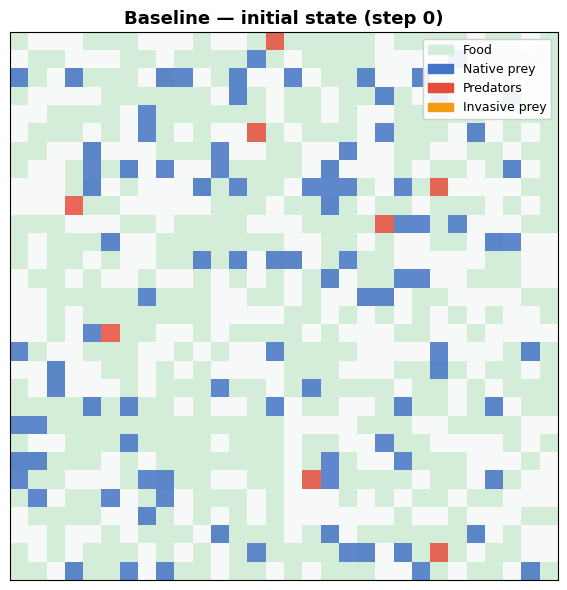

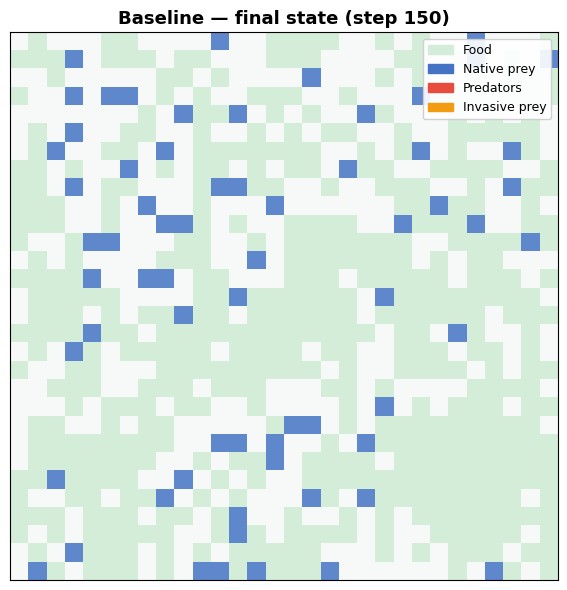

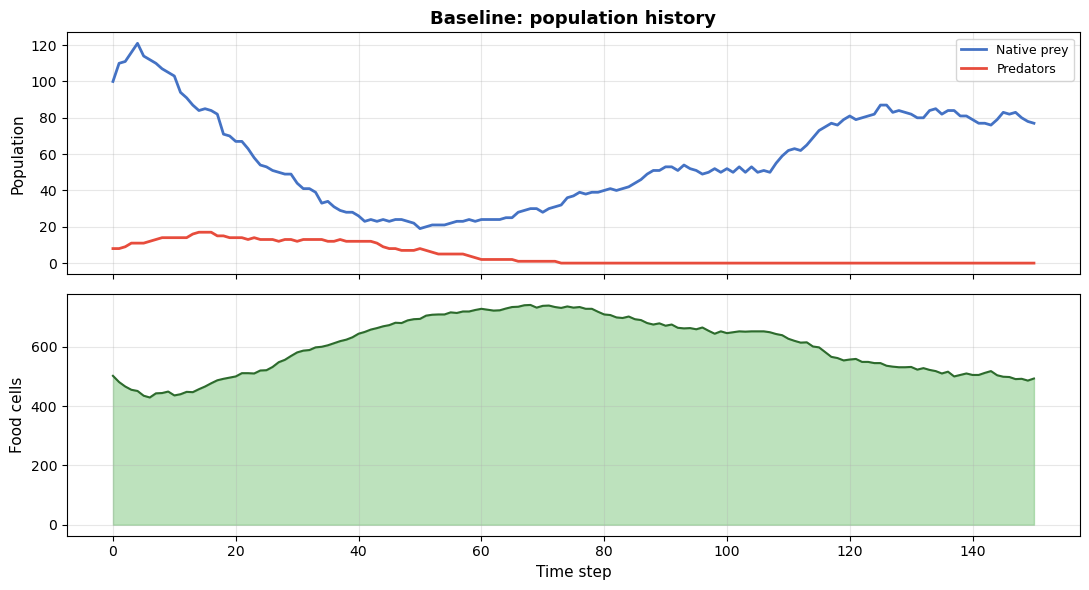

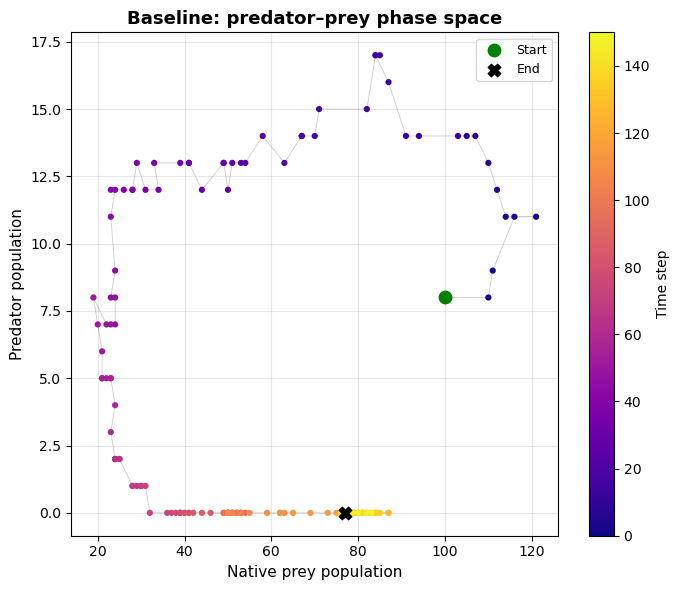

─────────────────────────────────────────────
Baseline final  native prey :    77
Baseline final  predators   :     0
Baseline final  food cells  :   493


In [53]:
set_seed(42)

BASELINE_STEPS = 150

eco_baseline = Ecosystem(
    width=30, height=30,
    initial_prey=100, initial_predators=8,
    food_regrowth_rate=0.07
)

plot_grid(eco_baseline, "Baseline — initial state (step 0)")

eco_baseline.run(steps=BASELINE_STEPS)

plot_grid(eco_baseline, f"Baseline — final state (step {BASELINE_STEPS})")
plot_population_history(eco_baseline, "Baseline: population history")
plot_phase(eco_baseline, "Baseline: predator–prey phase space")

print("─" * 45)
print(f"Baseline final  native prey : {len(eco_baseline.prey):>5}")
print(f"Baseline final  predators   : {len(eco_baseline.predators):>5}")
print(f"Baseline final  food cells  : {int(np.sum(eco_baseline.food_grid)):>5}")


## 6. Invaded experiment

This part introduces invasive prey after the baseline system has already started running. It then compares the invaded case with the baseline case using plots and repeated trials. This helps show how the invasive species changes native prey survival, predator survival, and the overall structure of the ecosystem.

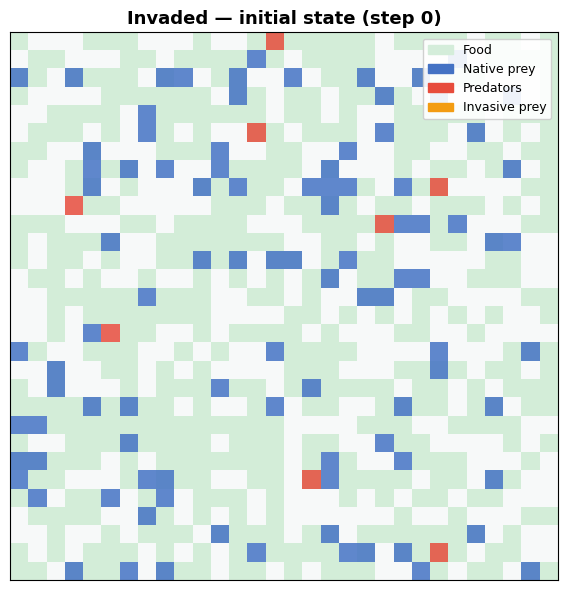

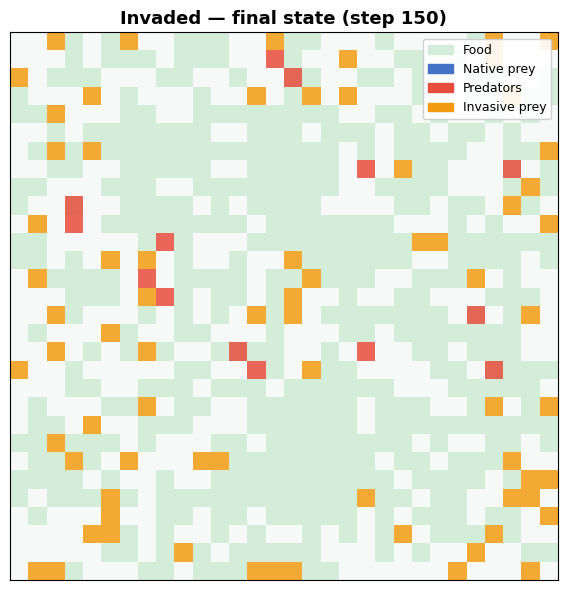

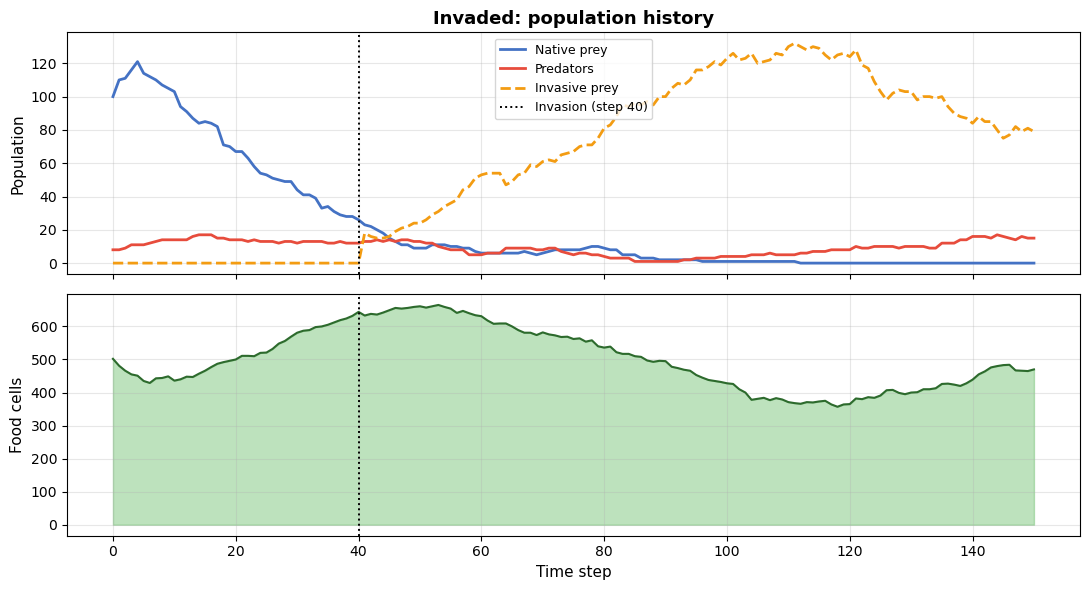

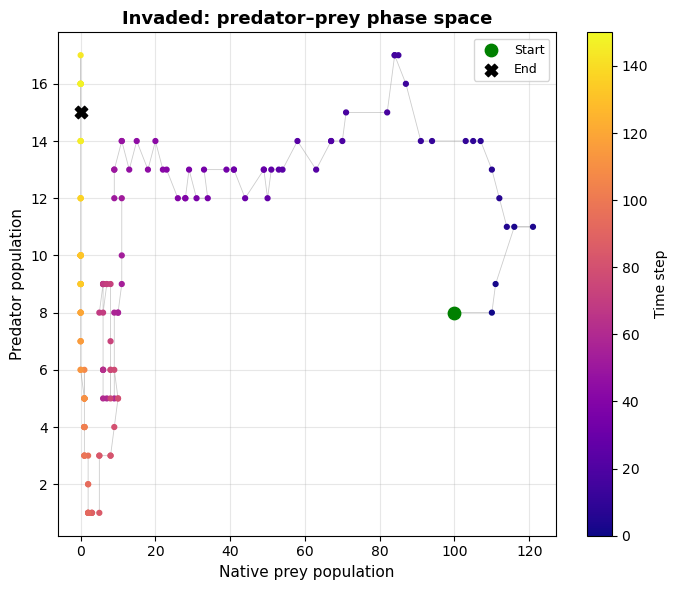

─────────────────────────────────────────────
Invaded final  native prey  :     0
Invaded final  predators    :    15
Invaded final  invasive prey:    79


In [54]:
set_seed(42)

INVASION_STEP  = 40
INVASION_COUNT = 16
TOTAL_STEPS    = 150

eco_invaded = Ecosystem(
    width=30, height=30,
    initial_prey=100, initial_predators=8,
    food_regrowth_rate=0.07
)

plot_grid(eco_invaded, "Invaded — initial state (step 0)")

eco_invaded.run(
    steps=TOTAL_STEPS,
    invasion_step=INVASION_STEP,
    invasion_count=INVASION_COUNT
)

plot_grid(eco_invaded, f"Invaded — final state (step {TOTAL_STEPS})")
plot_population_history(eco_invaded, "Invaded: population history", invasion_step=INVASION_STEP)
plot_phase(eco_invaded, "Invaded: predator–prey phase space")

print("─" * 45)
print(f"Invaded final  native prey  : {len(eco_invaded.prey):>5}")
print(f"Invaded final  predators    : {len(eco_invaded.predators):>5}")
print(f"Invaded final  invasive prey: {len(eco_invaded.invasive):>5}")


## 7. Side-by-side comparison
The 2×2 dashboard shows all three species and food availability for both runs on the same axes.

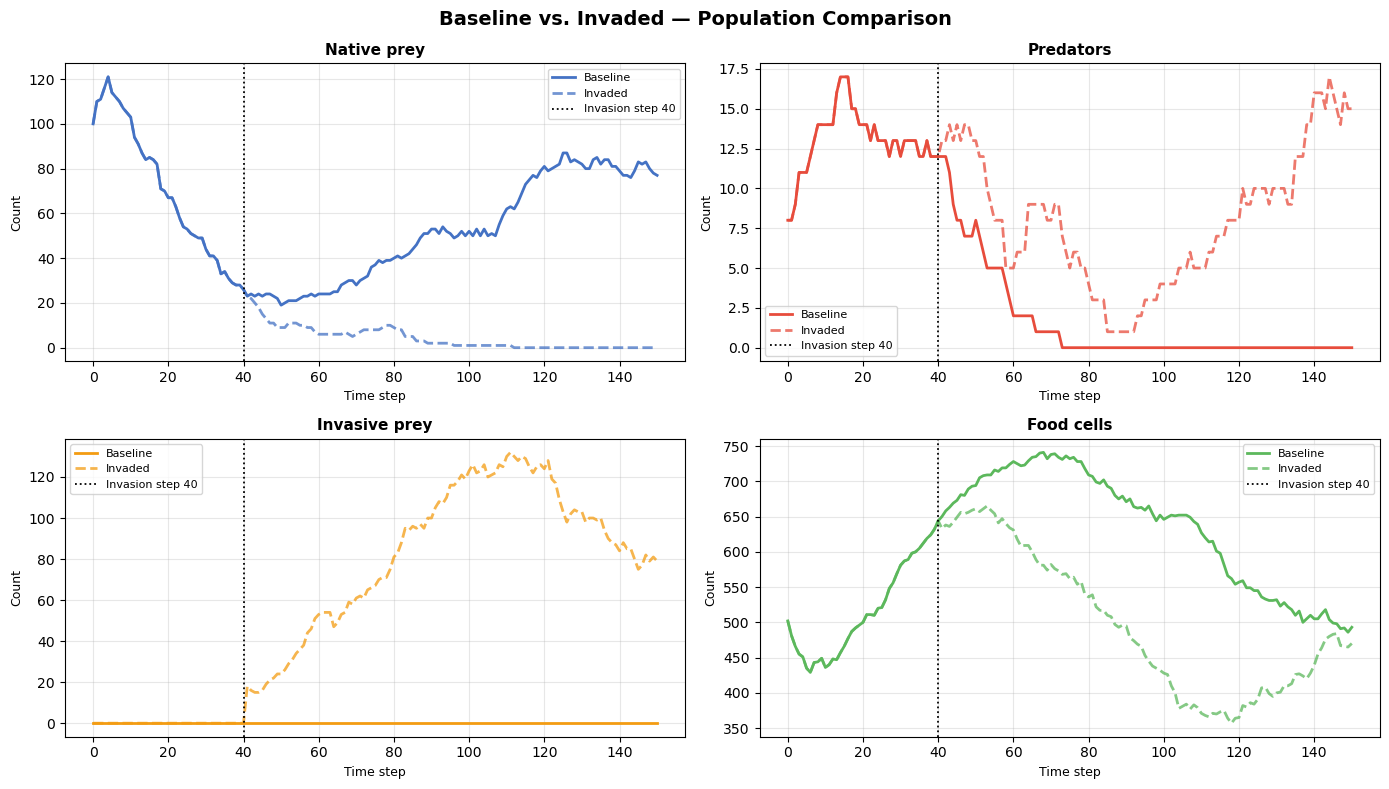

In [55]:
plot_comparison(eco_baseline, eco_invaded, invasion_step=INVASION_STEP)

## 8. Multi-trial analysis

Agent-based models are stochastic, a single seed may not represent typical behaviour.  
We run 20 independent seeds and compute:

- Mean ± 1 SD population ribbons over time  
- Extinction rates (how often does each species reach 0?)  
- Final-population summary statistics

In [56]:
def run_trial(seed: int, invaded: bool = False, steps: int = 150, invasion_step: int = 40, invasion_count: int = 16) -> dict:
    
    """
    Run one full simulation and return final counts + full histories.

    Parameters:
    seed : int
        Random seed for this trial.
    invaded : bool
        If True, introduce invasive prey at invasion_step.
    steps : int
        Total simulation steps.
    invasion_step : int
        Step at which invasive prey are introduced.
    invasion_count : int
        Number of invasive prey introduced.

    Returns:
    dict with keys: final_native, final_predators, final_invasive,
                    native_history, predator_history, invasive_history
    """
    
    set_seed(seed)
    eco = Ecosystem(
        width=30, height=30,
        initial_prey=100, initial_predators=8,
        food_regrowth_rate=0.07
    )
    
    if invaded:
        eco.run(steps=steps, invasion_step=invasion_step, invasion_count=invasion_count)
    else:
        eco.run(steps=steps)
    return {
        "final_native":      len(eco.prey),
        "final_predators":   len(eco.predators),
        "final_invasive":    len(eco.invasive),
        "native_history":    eco.prey_history,
        "predator_history":  eco.predator_history,
        "invasive_history":  eco.invasive_history,
    }


N_TRIALS = 20
seeds    = list(range(N_TRIALS))

print(f"Running {N_TRIALS} baseline trials...")
baseline_results = [run_trial(s, invaded=False)  for s in seeds]

print(f"Running {N_TRIALS} invaded trials...")
invaded_results  = [run_trial(s, invaded=True)   for s in seeds]

print("Done.")


Running 20 baseline trials...
Running 20 invaded trials...
Done.


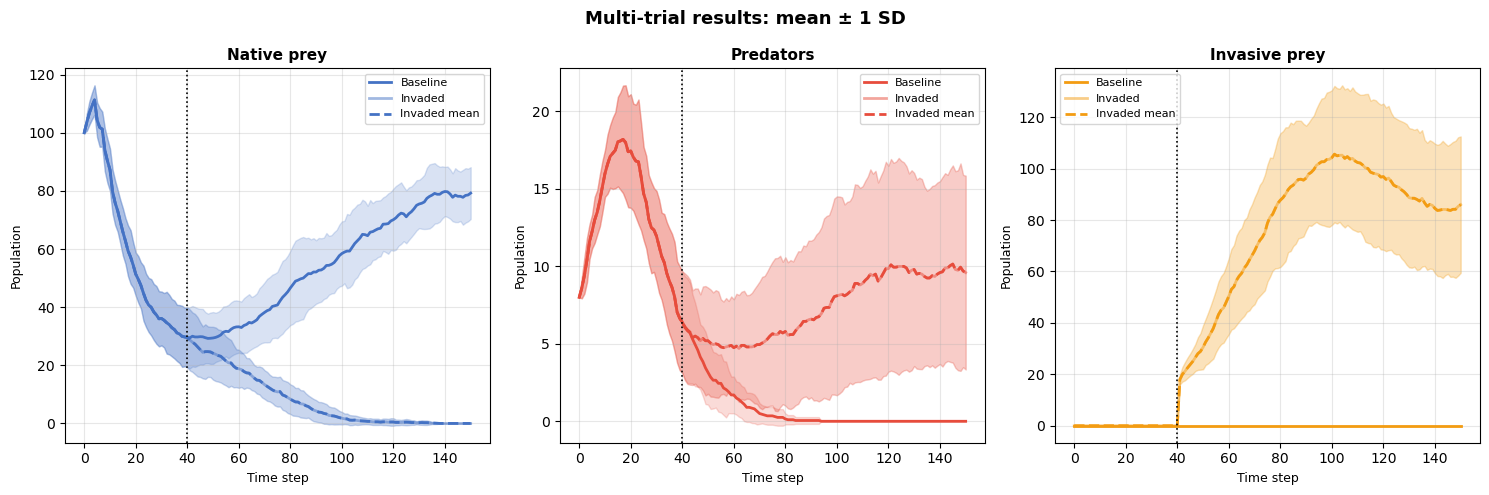

In [57]:
# Population ribbons
plot_trial_ribbons(baseline_results, invaded_results, invasion_step=INVASION_STEP)


In [58]:
# Summary statistics table
def summarise(results: list[dict], label: str) -> None:
    # Print mean, std, min, max for final populations across all trials.
    native    = [r["final_native"]    for r in results]
    preds     = [r["final_predators"] for r in results]
    invasive  = [r["final_invasive"]  for r in results]

    ext_native   = sum(1 for v in native   if v == 0)
    ext_preds    = sum(1 for v in preds    if v == 0)
    ext_invasive = sum(1 for v in invasive if v == 0)

    print(f"\n{'═'*52}")
    print(f"  {label}  ({len(results)} trials)")
    print(f"{'─'*52}")
    print(f"  {'Species':<20} {'Mean':>7} {'Std':>7} {'Min':>5} {'Max':>5}  Extinct")
    print(f"{'─'*52}")
    
    for name, vals, ext in [
        ("Native prey",   native,   ext_native),
        ("Predators",     preds,    ext_preds),
        ("Invasive prey", invasive, ext_invasive),
    ]:
        print(f"  {name:<20} {np.mean(vals):>7.1f} {np.std(vals):>7.1f} "
              f"{min(vals):>5} {max(vals):>5}  {ext}/{len(results)}")
    print(f"{'═'*52}")


summarise(baseline_results, "BASELINE")
summarise(invaded_results,  "INVADED ")



════════════════════════════════════════════════════
  BASELINE  (20 trials)
────────────────────────────────────────────────────
  Species                 Mean     Std   Min   Max  Extinct
────────────────────────────────────────────────────
  Native prey             79.2     8.9    61    97  0/20
  Predators                0.0     0.0     0     0  20/20
  Invasive prey            0.0     0.0     0     0  20/20
════════════════════════════════════════════════════

════════════════════════════════════════════════════
  INVADED   (20 trials)
────────────────────────────────────────────────────
  Species                 Mean     Std   Min   Max  Extinct
────────────────────────────────────────────────────
  Native prey              0.0     0.0     0     0  20/20
  Predators                9.6     6.3     0    20  3/20
  Invasive prey           86.0    26.5    39   133  0/20
════════════════════════════════════════════════════


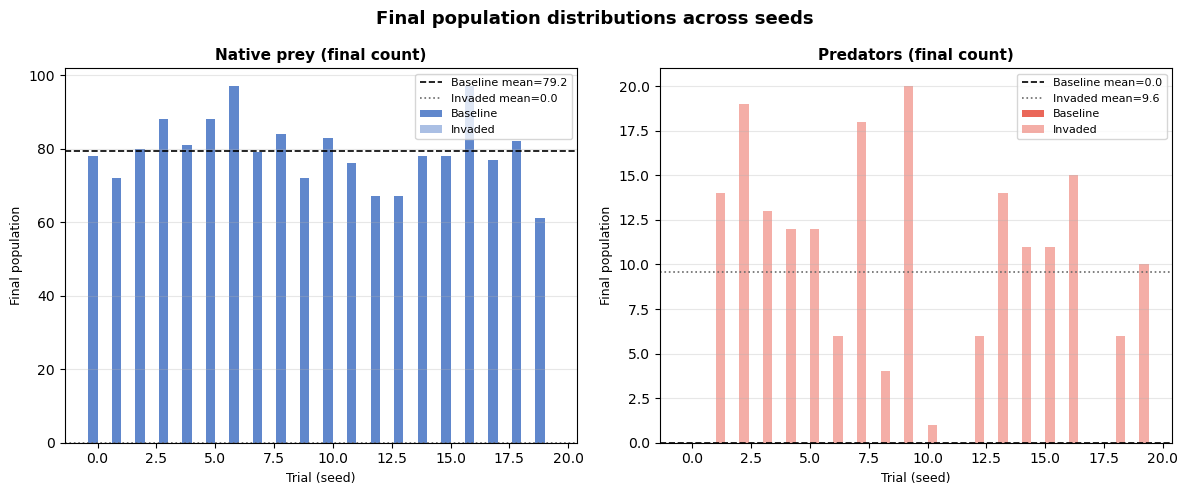

In [59]:
# Final-population scatter: baseline vs. invaded
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Final population distributions across seeds", fontsize=13, fontweight="bold")

for ax, key, color, title in [
    (axes[0], "final_native",    NATIVE_COLOR, "Native prey (final count)"),
    (axes[1], "final_predators", PRED_COLOR,   "Predators (final count)"),
]:
    base_vals = [r[key] for r in baseline_results]
    inv_vals  = [r[key] for r in invaded_results]
    x = np.arange(N_TRIALS)
    ax.bar(x - 0.2, base_vals, width=0.4, label="Baseline", color=color, alpha=0.85)
    ax.bar(x + 0.2, inv_vals,  width=0.4, label="Invaded",  color=color, alpha=0.45)
    ax.axhline(np.mean(base_vals), color="black",    lw=1.2, linestyle="--", label=f"Baseline mean={np.mean(base_vals):.1f}")
    ax.axhline(np.mean(inv_vals),  color="dimgray",  lw=1.2, linestyle=":",  label=f"Invaded mean={np.mean(inv_vals):.1f}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Trial (seed)", fontsize=9)
    ax.set_ylabel("Final population", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Conclusion

Overall, this notebook shows how a computational model can be used to study ecosystem behavior. By comparing the baseline and invaded systems, the model helps explain how an invasive species can change population balance, competition, and long-term survival in the food web.